In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/workspaces/Machine-Learning-ZoomCamp/car_features_msrp.csv')

In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
idx = df[df.columns[df.dtypes == 'str']]

for col in idx:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [7]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

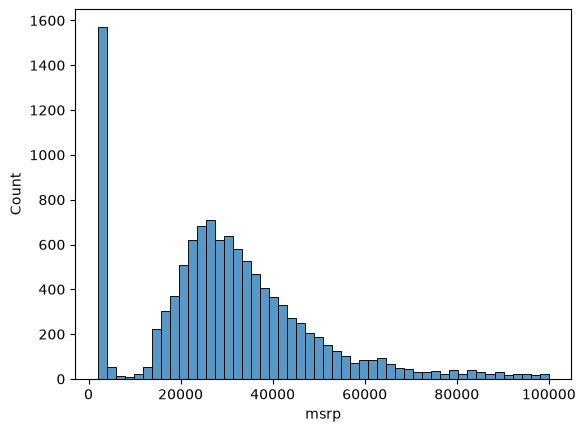

In [9]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [10]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

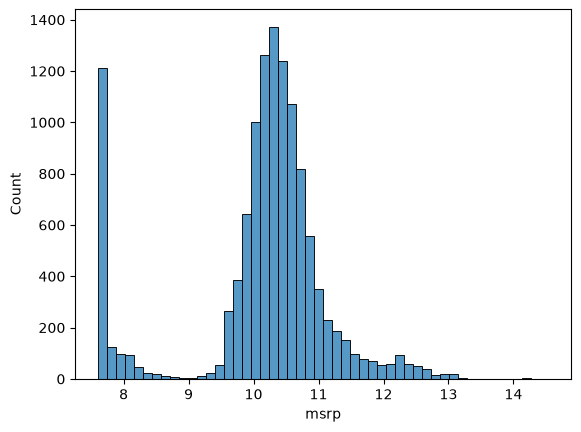

In [11]:
sns.histplot(price_logs, bins=50)

In [12]:
n = len(df)

train = int(n * 0.6)
val = int(n * 0.2)
test = n - (train + val)

In [13]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

In [14]:
train_df = df.iloc[idx[:train]]
val_df = df.iloc[idx[train:val+train]]
test_df = df.iloc[idx[(train+val):]]

In [15]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [16]:
target_train = np.log1p(train_df.msrp.values)
target_val = np.log1p(val_df.msrp.values)
target_test = np.log1p(test_df.msrp.values)

In [17]:
del train_df['msrp']
del test_df['msrp']
del val_df['msrp']

In [66]:
def train_linear_regression(X, Y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(Y)

    return w[0], w[1:]

def predict(X, w):    
    return X.dot(w)

def RMSE(pred, tar):
    sum = 0
    for i in range(len(pred)):
        sum += (pred[i]-tar[i])**2

    sum /= len(pred)

    return np.sqrt(sum)

In [52]:
cols = base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [53]:
X_train = train_df[cols]
X_train = X_train.fillna(0).values
w0, ws = train_linear_regression(X_train, target_train)


In [62]:
predictions = w0 + predict(X_train, ws)


<Axes: ylabel='Count'>

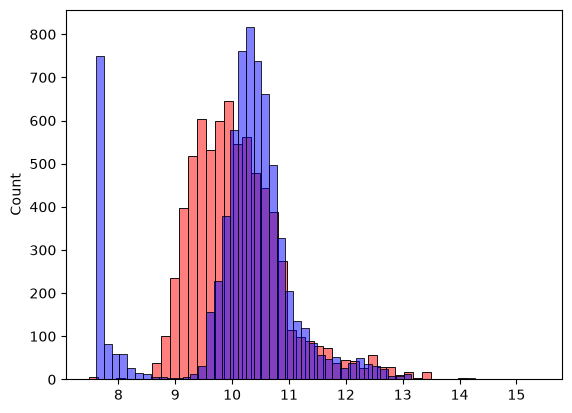

In [64]:
sns.histplot(predictions, color='red', alpha=0.5, bins=50)
sns.histplot(target_train, color='blue', alpha=0.5, bins=50)

In [67]:
RMSE(predictions, target_train)

np.float64(0.7554591756909299)